In [83]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 
import seaborn as sns 

In [84]:
wine = pd.read_csv("winequality-red.csv")  

In [85]:
wine

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


<Axes: >

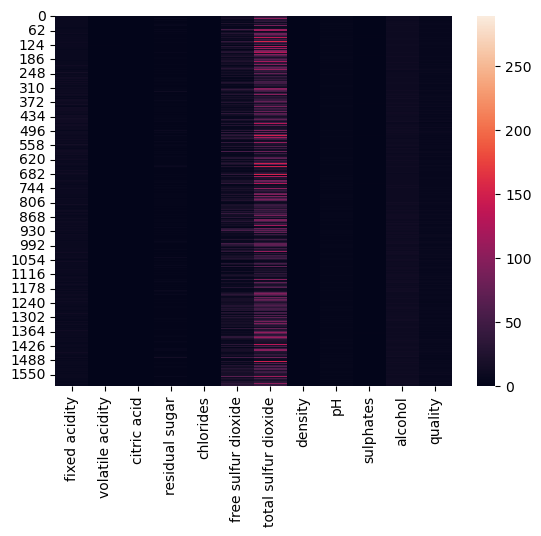

In [86]:
sns.heatmap(wine)

In [87]:
df = wine.copy()

In [88]:
df.shape

(1599, 12)

In [89]:
df.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

In [90]:
#sns.pairplot(dataframe)

In [91]:
df.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [92]:
X = df.drop("quality",axis=1)

In [93]:
y = df["quality"]

y.value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

Text(0.5, 1.0, 'Correlation between our variables')

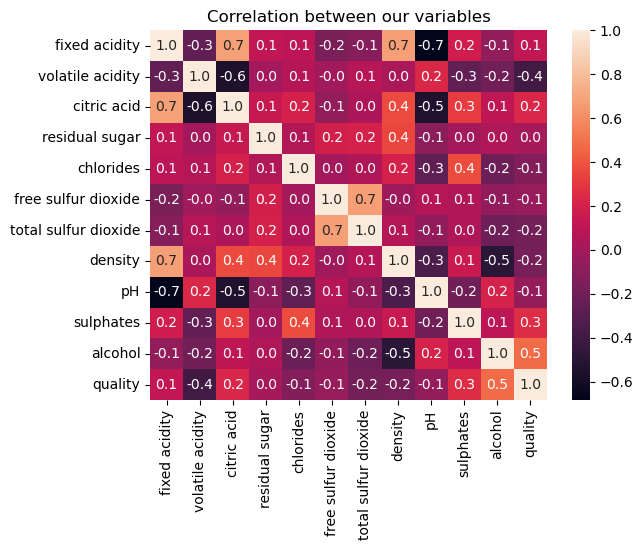

In [94]:
sns.heatmap(df.corr(),annot=True,fmt=".1f")
plt.title("Correlation between our variables")

<Axes: >

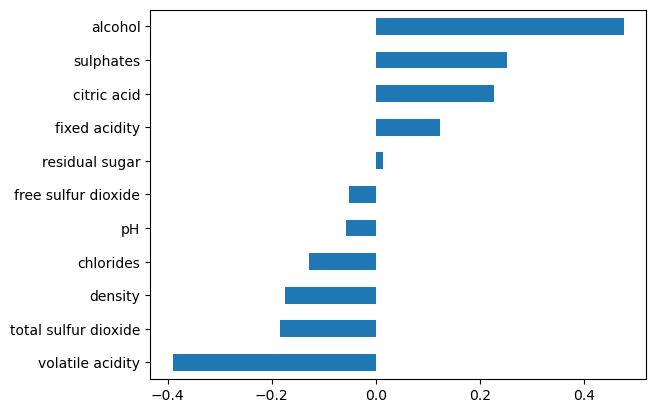

In [95]:
cor = X.join(y).corr()["quality"].drop("quality")
cors = cor.copy()
cor.sort_values().plot(kind="barh")

<Axes: >

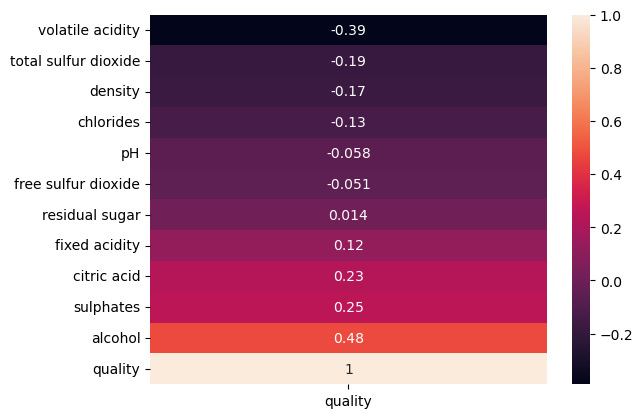

In [96]:
corr_gr = df.corr()[["quality"]].sort_values(by="quality")

sns.heatmap(corr_gr,annot=True)

<Axes: ylabel='quality'>

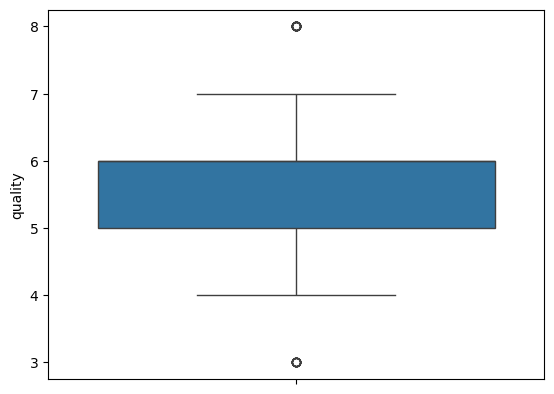

In [97]:
sns.boxplot(y) 

## Preprocessing

In [98]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

In [99]:
#Quality 7 or higher is 'Good' (1), 6 or lower is 'Bad' (0)

df['quality'] = df['quality'].apply(lambda x: 1 if x >= 7 else 0)

df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,0
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,0
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,0
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,0
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,0
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,0
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,0


In [100]:
X = df.drop("quality",axis=1)
y = df["quality"]

In [101]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from imblearn.over_sampling import SMOTE 

In [102]:
#. Handle Imbalance data with SMOTE
# This creates synthetic samples for the "Good" category so the model learns better

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

In [103]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

In [104]:
from sklearn.preprocessing import RobustScaler

normalizer = RobustScaler()

X_train = normalizer.fit_transform(X_train)
X_test = normalizer.transform(X_test)

In [105]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) 

In [106]:

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)


RandomForestClassifier(random_state=42)

In [107]:
y_pred = model.predict(X_test_scaled)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print()
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2%}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[260  31]
 [  6 256]]

Accuracy Score: 93.31%

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.89      0.93       291
           1       0.89      0.98      0.93       262

    accuracy                           0.93       553
   macro avg       0.93      0.94      0.93       553
weighted avg       0.94      0.93      0.93       553



In [108]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [109]:
MAE = mean_absolute_error(y_test,y_pred)
MSE = np.sqrt(mean_squared_error(y_test,y_pred))

print(MAE)
print(MSE)

0.06690777576853527
0.2586653741197984


In [112]:
from sklearn.model_selection import learning_curve

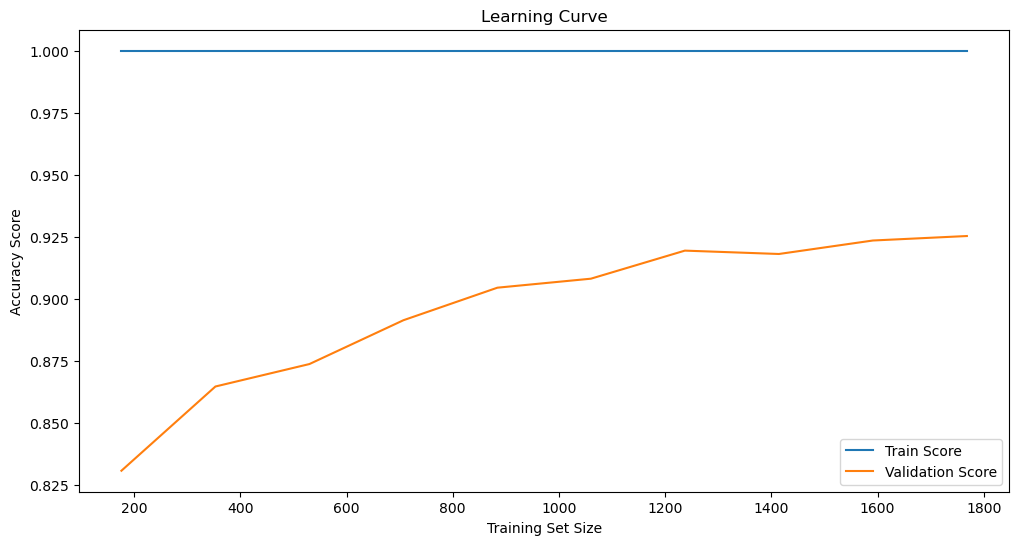

In [113]:
N,train_score,val_score = learning_curve(model,X_train_scaled,
                                         y_train,train_sizes=np.linspace(0.1,1,10)
                                         ,cv=5,scoring="accuracy")


plt.figure(figsize=(12,6))   
plt.plot(N,train_score.mean(axis=1),label="Train Score")
plt.plot(N,val_score.mean(axis=1),label="Validation Score")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy Score")
plt.title("Learning Curve")
plt.legend()
plt.show()                           